# Lorentzian Representation / Compression Error

(a) Fit each `S(\omega)` in the `dipole_polarizability_160Yb` dataset with 2, 3, ..., `N_MAX` Lorentzians and measure reconstruction error using strength-function-only objectives.

Below is a sweep cell given an input `N_MAX`. Results are cached under `tests/cache/yb_lorentzian_compression/`, so increasing `N_MAX` only fits the newly requested values.

## Setup

In [2]:
from __future__ import annotations

import json
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = Path.cwd()
if not (ROOT / "Dipole_polarizability").exists() and ROOT.name == "tests":
    ROOT = ROOT.parent
if not (ROOT / "Dipole_polarizability").exists():
    raise RuntimeError("Run this notebook from the SMLR repository root or from SMLR/tests.")

sys.path.insert(0, str(ROOT / "Dipole_polarizability" / "src"))
sys.path.insert(0, str(ROOT / "src"))

import helper_gpt  # noqa: E402

plt.rcParams.update({"figure.dpi": 130, "axes.grid": True})
print("Repository root:", ROOT)
print("Using helper:", Path(helper_gpt.__file__).resolve())

Repository root: /Users/laurenjin/Documents/projects/SMLR-tests/SMLR
Using helper: /Users/laurenjin/Documents/projects/SMLR-tests/SMLR/Dipole_polarizability/src/helper_gpt.py


## Configuration

In [3]:
# Main control: fit 2, 3, ..., N_MAX Lorentzians.
N_MAX = 30
N_MIN = 2

# Fitting conventions. ETA is the full Lorentzian width used by the existing dipole code.
ETA = 2.0
MIN_SPACING = 0.01
GRID_M = None  # None means use the full omega grid for NNLS initialization.

# Parameter-space subset for this compression test.
FILTER_RANGES = {"p1": [0.4, 1.8], "p2": [1.5, 4.0]}

# Optional extra throttle for quick smoke tests after filtering.
SAMPLE_LIMIT = None
FORCE_REFIT = False

STRENGTH_DIR = ROOT / "dipole_polarizability_160Yb" / "total_strength"
ALPHAD_DIR = ROOT / "dipole_polarizability_160Yb" / "total_alphaD"
CACHE_DIR = ROOT / "tests" / "cache" / "yb_lorentzian_compression"
CACHE_DIR.mkdir(parents=True, exist_ok=True)

print("Strength directory:", STRENGTH_DIR)
print("Cache directory:", CACHE_DIR)

Strength directory: /Users/laurenjin/Documents/projects/SMLR-tests/SMLR/dipole_polarizability_160Yb/total_strength
Cache directory: /Users/laurenjin/Documents/projects/SMLR-tests/SMLR/tests/cache/yb_lorentzian_compression


## Load Strength Data

In [4]:
dataset = helper_gpt.load_dataset(
    strength_dir=str(STRENGTH_DIR),
    alphaD_dir=str(ALPHAD_DIR),
    strength_regex=r"strength_(?P<p2>[0-9.]+)_(?P<p1>[0-9.]+)\.out",
    filter_ranges=FILTER_RANGES,
)

if SAMPLE_LIMIT is not None:
    keep = np.arange(min(int(SAMPLE_LIMIT), len(dataset.strengths)))
    dataset.strengths = [dataset.strengths[i] for i in keep]
    dataset.sample_ids = [dataset.sample_ids[i] for i in keep]
    dataset.param_values = dataset.param_values[keep]
    dataset.alphaD_values = dataset.alphaD_values[keep]

omega = np.asarray(dataset.strengths[0][:, 0], dtype=np.float32)
for i, strength in enumerate(dataset.strengths[1:], start=1):
    if strength.shape[0] != omega.size or not np.allclose(strength[:, 0], omega):
        raise ValueError(f"Spectrum {i} does not share the common omega grid.")

strength_matrix = np.stack([np.asarray(s[:, 1], dtype=np.float32) for s in dataset.strengths], axis=0)
print(f"Loaded {len(dataset.strengths)} spectra on {omega.size} omega points.")
print("Parameter names:", dataset.param_names)
display(pd.DataFrame(dataset.param_values, columns=dataset.param_names).describe())

Loaded 121 spectra on 400 omega points.
Parameter names: ['p1', 'p2']


,p1,p2
count,121.000000,121.000000
mean,1.100000,2.750000
std,0.408302,0.793857
min,0.457000,1.500000
25%,0.714000,2.000000
50%,1.100000,2.750000
75%,1.486000,3.500000
max,1.743000,4.000000


## Fit And Score Helpers

The fit objective is strength-only. AlphaD below is included only as a derived diagnostic of how the compressed curve changes the inverse-energy moment.

In [5]:
def trapz_weights(x: np.ndarray) -> np.ndarray:
    x = np.asarray(x, dtype=np.float64)
    dx = np.diff(x)
    w = np.empty_like(x)
    w[0] = dx[0] / 2.0
    w[-1] = dx[-1] / 2.0
    w[1:-1] = (x[2:] - x[:-2]) / 2.0
    return w


OMEGA_WEIGHTS = trapz_weights(omega)


def alphaD_from_strength(y: np.ndarray) -> float:
    return float(helper_gpt.ALPHAD_FAC * np.trapz(y / np.maximum(omega, 1e-6), omega))


def score_fit(y: np.ndarray, yhat: np.ndarray) -> dict[str, float]:
    y = np.asarray(y, dtype=np.float64)
    yhat = np.asarray(yhat, dtype=np.float64)
    residual = yhat - y
    rmse = float(np.sqrt(np.mean(residual ** 2)))
    wrmse = float(np.sqrt(np.sum(OMEGA_WEIGHTS * residual ** 2) / np.sum(OMEGA_WEIGHTS)))
    l2_true = float(np.sqrt(np.sum(OMEGA_WEIGHTS * y ** 2)))
    rel_l2 = float(np.sqrt(np.sum(OMEGA_WEIGHTS * residual ** 2)) / max(l2_true, 1e-12))
    denom_var = float(np.sum((y - np.mean(y)) ** 2))
    r2 = float(1.0 - np.sum(residual ** 2) / denom_var) if denom_var > 0 else np.nan
    alphaD_true = alphaD_from_strength(y)
    alphaD_hat = alphaD_from_strength(yhat)
    return {
        "rmse": rmse,
        "weighted_rmse": wrmse,
        "mae": float(np.mean(np.abs(residual))),
        "max_abs": float(np.max(np.abs(residual))),
        "rel_l2": rel_l2,
        "nrmse_peak": float(rmse / max(np.max(np.abs(y)), 1e-12)),
        "nrmse_range": float(rmse / max(np.ptp(y), 1e-12)),
        "r2": r2,
        "alphaD_true_from_strength": alphaD_true,
        "alphaD_hat_from_compressed_strength": alphaD_hat,
        "alphaD_relerr_from_compressed_strength": float(abs(alphaD_hat - alphaD_true) / max(abs(alphaD_true), 1e-12)),
    }


def sample_cache_path(sample_index: int, n_lorentz: int) -> Path:
    sid = "_".join(dataset.sample_ids[sample_index])
    return CACHE_DIR / f"sample{sample_index:03d}_{sid}_n{n_lorentz:02d}_eta{ETA:g}_spacing{MIN_SPACING:g}.npz"


def fit_one(sample_index: int, n_lorentz: int, force: bool = False) -> dict:
    path = sample_cache_path(sample_index, n_lorentz)
    y = strength_matrix[sample_index]
    if path.exists() and not force:
        packed = np.load(path, allow_pickle=False)
        E = packed["E"]
        B = packed["B"]
        yhat = packed["yhat"]
        elapsed = float(packed.get("elapsed_seconds", np.array(np.nan)))
    else:
        start = time.perf_counter()
        E, B, yhat = helper_gpt.fit_strength_with_tf_lorentzian(
            omega,
            y,
            int(n_lorentz),
            float(ETA),
            grid_M=GRID_M,
            min_spacing=float(MIN_SPACING),
        )
        elapsed = time.perf_counter() - start
        np.savez_compressed(path, E=E, B=B, yhat=yhat, elapsed_seconds=np.array(elapsed))

    scores = score_fit(y, yhat)
    return {
        "sample_index": sample_index,
        "n_lorentz": int(n_lorentz),
        "elapsed_seconds": elapsed,
        "p1": float(dataset.param_values[sample_index, 0]),
        "p2": float(dataset.param_values[sample_index, 1]),
        "sample_id": "_".join(dataset.sample_ids[sample_index]),
        **scores,
    }


def run_sweep(n_min: int = N_MIN, n_max: int = N_MAX, force: bool = FORCE_REFIT) -> pd.DataFrame:
    rows = []
    n_values = list(range(int(n_min), int(n_max) + 1))
    total = len(n_values) * len(dataset.strengths)
    count = 0
    start = time.perf_counter()
    for n_lorentz in n_values:
        for sample_index in range(len(dataset.strengths)):
            rows.append(fit_one(sample_index, n_lorentz, force=force))
            count += 1
            if count == 1 or count % 25 == 0 or count == total:
                print(f"{count:4d}/{total} fits scored after {time.perf_counter() - start:7.1f} s", end="\r")
    print()
    df = pd.DataFrame(rows)
    out_csv = CACHE_DIR / f"summary_n{n_min}_to_n{n_max}_eta{ETA:g}_spacing{MIN_SPACING:g}.csv"
    df.to_csv(out_csv, index=False)
    print("Saved summary:", out_csv)
    return df

## Run The Compression Sweep

In [6]:
results = run_sweep()
summary = (
    results.groupby("n_lorentz")
    .agg(
        spectra=("sample_index", "count"),
        rmse_mean=("rmse", "mean"),
        rmse_median=("rmse", "median"),
        rmse_p90=("rmse", lambda x: np.quantile(x, 0.90)),
        rel_l2_mean=("rel_l2", "mean"),
        rel_l2_median=("rel_l2", "median"),
        rel_l2_p90=("rel_l2", lambda x: np.quantile(x, 0.90)),
        nrmse_peak_median=("nrmse_peak", "median"),
        max_abs_p90=("max_abs", lambda x: np.quantile(x, 0.90)),
        r2_median=("r2", "median"),
        alphaD_relerr_median=("alphaD_relerr_from_compressed_strength", "median"),
    )
    .reset_index()
)
display(summary)

/var/folders/jb/056vg5td3x140pfzlhf0s5hr0000gn/T/ipykernel_19475/1902416924.py:15: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(helper_gpt.ALPHAD_FAC * np.trapz(y / np.maximum(omega, 1e-6), omega))


3509/3509 fits scored after     1.6 s
Saved summary: /Users/laurenjin/Documents/projects/SMLR-tests/SMLR/tests/cache/yb_lorentzian_compression/summary_n2_to_n30_eta2_spacing0.01.csv


,n_lorentz,spectra,rmse_mean,rmse_median,rmse_p90,rel_l2_mean,rel_l2_median,rel_l2_p90,nrmse_peak_median,max_abs_p90,r2_median,alphaD_relerr_median
0,2,121,0.768934,0.758080,0.856899,0.306158,0.316544,0.357724,0.094473,3.636926,0.852207,0.111923
1,3,121,0.332845,0.273144,0.502176,0.134511,0.105110,0.220835,0.031604,1.270371,0.983973,0.027832
2,4,121,0.244624,0.227147,0.347121,0.100142,0.084918,0.165161,0.025265,1.013994,0.989240,0.035571
3,5,121,0.193990,0.193515,0.279328,0.079470,0.071643,0.128401,0.020600,0.890982,0.992743,0.038853
4,6,121,0.161362,0.169702,0.229101,0.065895,0.067913,0.109272,0.019068,0.798887,0.993421,0.039902
5,7,121,0.143190,0.136693,0.199683,0.058307,0.059963,0.086238,0.018037,0.764567,0.994685,0.047409
6,8,121,0.127184,0.107112,0.185851,0.051766,0.041360,0.079650,0.012466,0.706286,0.997557,0.062771
7,9,121,0.114191,0.104671,0.166775,0.046188,0.039186,0.072260,0.011525,0.706640,0.997762,0.069984
8,10,121,0.104901,0.101419,0.134862,0.041986,0.037775,0.064478,0.011242,0.713370,0.997909,0.073791
9,11,121,0.100480,0.098009,0.129875,0.040130,0.036788,0.052574,0.011089,0.713986,0.998028,0.075732


## Error Versus Number Of Lorentzians

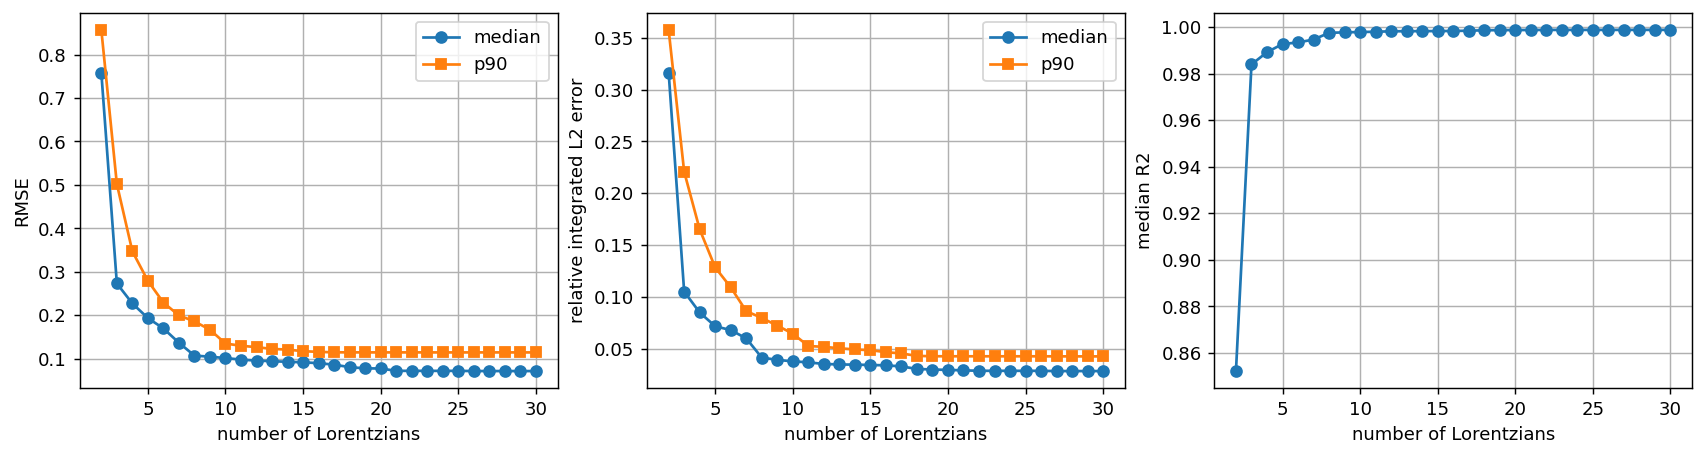

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.4), constrained_layout=True)

axes[0].plot(summary["n_lorentz"], summary["rmse_median"], marker="o", label="median")
axes[0].plot(summary["n_lorentz"], summary["rmse_p90"], marker="s", label="p90")
axes[0].set_xlabel("number of Lorentzians")
axes[0].set_ylabel("RMSE")
axes[0].legend()

axes[1].plot(summary["n_lorentz"], summary["rel_l2_median"], marker="o", label="median")
axes[1].plot(summary["n_lorentz"], summary["rel_l2_p90"], marker="s", label="p90")
axes[1].set_xlabel("number of Lorentzians")
axes[1].set_ylabel("relative integrated L2 error")
axes[1].legend()

axes[2].plot(summary["n_lorentz"], summary["r2_median"], marker="o")
axes[2].set_xlabel("number of Lorentzians")
axes[2].set_ylabel("median R2")

plt.show()

## Distribution And Worst Cases

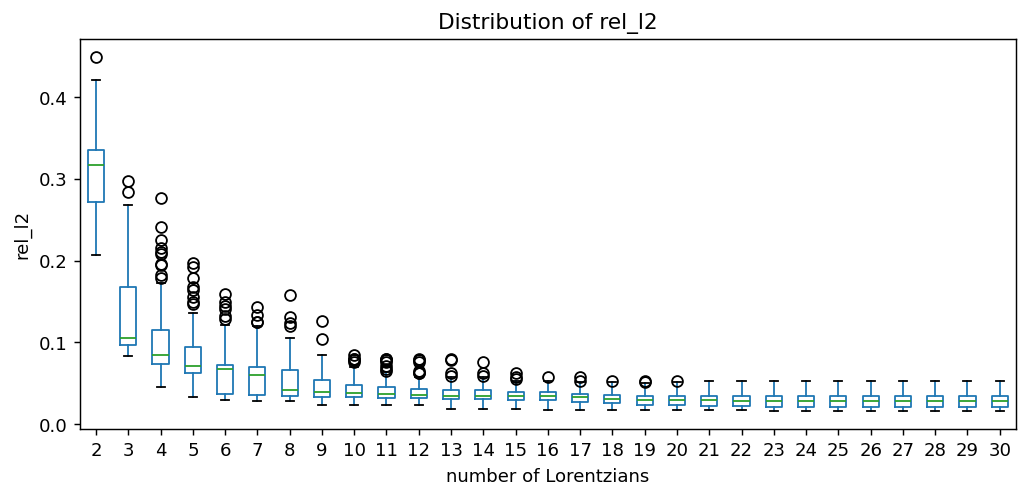

,n_lorentz,sample_index,sample_id,p1,p2,rmse,rel_l2,nrmse_peak,r2
110,2,110,0.4570_4.0000,0.457,4.00,0.825623,0.448932,0.184287,0.619000
99,2,99,0.4570_3.7500,0.457,3.75,0.798920,0.420602,0.173844,0.679195
111,2,111,0.5860_4.0000,0.586,4.00,0.784359,0.413475,0.171516,0.694911
88,2,88,0.4570_3.5000,0.457,3.50,0.771421,0.392329,0.154417,0.731261
100,2,100,0.5860_3.7500,0.586,3.75,0.761251,0.388554,0.151954,0.738980
...,...,...,...,...,...,...,...,...,...
3486,30,98,1.7430_3.5000,1.743,3.50,0.137024,0.052720,0.013934,0.996036
3497,30,109,1.7430_3.7500,1.743,3.75,0.130115,0.051233,0.013667,0.996228
3475,30,87,1.7430_3.2500,1.743,3.25,0.133809,0.050268,0.013344,0.996424
3474,30,86,1.6140_3.2500,1.614,3.25,0.129962,0.049735,0.013301,0.996481


In [9]:
metric = "rel_l2"

fig, ax = plt.subplots(figsize=(9, 4))
results.boxplot(column=metric, by="n_lorentz", ax=ax, grid=False)
ax.set_title(f"Distribution of {metric}")
ax.set_xlabel("number of Lorentzians")
ax.set_ylabel(metric)
fig.suptitle("")
plt.show()

display(
    results.sort_values(["n_lorentz", metric], ascending=[True, False])
    .groupby("n_lorentz")
    .head(5)[["n_lorentz", "sample_index", "sample_id", "p1", "p2", "rmse", "rel_l2", "nrmse_peak", "r2"]]
)

## Inspect A Spectrum Fit

ipywidgets unavailable; using static plot instead: No module named 'ipywidgets'


/var/folders/jb/056vg5td3x140pfzlhf0s5hr0000gn/T/ipykernel_19475/1902416924.py:15: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(helper_gpt.ALPHAD_FAC * np.trapz(y / np.maximum(omega, 1e-6), omega))


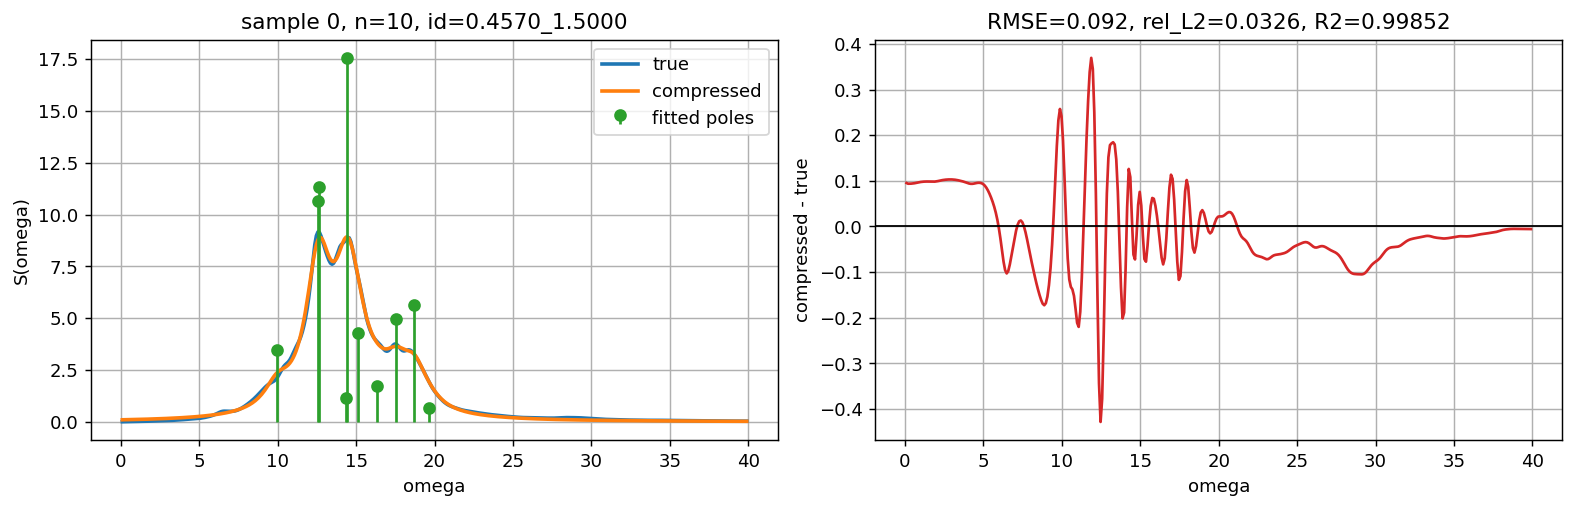

,E,B
0,9.970637,3.466151
1,12.599908,10.661633
2,12.617861,11.327479
3,14.350701,1.146892
4,14.448393,17.554850
5,15.112482,4.295965
6,16.333118,1.741180
7,17.552504,4.960153
8,18.721563,5.622112
9,19.647732,0.651612


In [37]:
def load_fit_arrays(sample_index: int, n_lorentz: int):
    fit_one(sample_index, n_lorentz, force=False)
    packed = np.load(sample_cache_path(sample_index, n_lorentz), allow_pickle=False)
    return packed["E"], packed["B"], packed["yhat"]


def plot_fit(sample_index: int = 0, n_lorentz: int = N_MAX):
    E, B, yhat = load_fit_arrays(int(sample_index), int(n_lorentz))
    y = strength_matrix[int(sample_index)]
    row = fit_one(int(sample_index), int(n_lorentz), force=False)

    fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), constrained_layout=True)
    axes[0].plot(omega, y, label="true", lw=2)
    axes[0].plot(omega, yhat, label="compressed", lw=2)
    axes[0].stem(E, B, linefmt="C2-", markerfmt="C2o", basefmt=" ", label="fitted poles")
    axes[0].set_xlabel("omega")
    axes[0].set_ylabel("S(omega)")
    axes[0].set_title(f"sample {sample_index}, n={n_lorentz}, id={row['sample_id']}")
    axes[0].legend()

    axes[1].plot(omega, yhat - y, color="C3")
    axes[1].axhline(0.0, color="black", lw=1)
    axes[1].set_xlabel("omega")
    axes[1].set_ylabel("compressed - true")
    axes[1].set_title(f"RMSE={row['rmse']:.4g}, rel_L2={row['rel_l2']:.4g}, R2={row['r2']:.5f}")
    plt.show()

    display(pd.DataFrame({"E": E, "B": B}))


try:
    import ipywidgets as widgets
    from IPython.display import clear_output

    worst_at_n = results.loc[results.groupby("n_lorentz")["rel_l2"].idxmax()].set_index("n_lorentz")
    n_slider = widgets.IntSlider(value=N_MAX, min=N_MIN, max=N_MAX, step=1, description="n")
    sample_slider = widgets.IntSlider(value=0, min=0, max=len(dataset.strengths) - 1, step=1, description="sample")
    worst_button = widgets.Button(description="Use worst sample")
    out = widgets.Output()

    def refresh(*_):
        with out:
            clear_output(wait=True)
            plot_fit(sample_slider.value, n_slider.value)

    def use_worst(_):
        sample_slider.value = int(worst_at_n.loc[n_slider.value, "sample_index"])

    n_slider.observe(refresh, names="value")
    sample_slider.observe(refresh, names="value")
    worst_button.on_click(use_worst)
    display(widgets.HBox([n_slider, sample_slider, worst_button]), out)
    refresh()
except Exception as exc:
    print("ipywidgets unavailable; using static plot instead:", exc)
    plot_fit(sample_index=0, n_lorentz=10)

## Acceptance Threshold Helper

Set the thresholds to match what you consider acceptable compression. This reports the first `n` where both the median and p90 satisfy the thresholds.

In [18]:
REL_L2_MEDIAN_THRESHOLD = 0.05
REL_L2_P90_THRESHOLD = 0.10

acceptable = summary[
    (summary["rel_l2_median"] <= REL_L2_MEDIAN_THRESHOLD)
    & (summary["rel_l2_p90"] <= REL_L2_P90_THRESHOLD)
]

if len(acceptable):
    best_n = int(acceptable.iloc[0]["n_lorentz"])
    print(f"First acceptable n: {best_n}")
else:
    print("No n in this sweep met the current thresholds.")

display(summary[["n_lorentz", "rel_l2_median", "rel_l2_p90", "rmse_median", "rmse_p90", "r2_median"]])

First acceptable n: 8


,n_lorentz,rel_l2_median,rel_l2_p90,rmse_median,rmse_p90,r2_median
0,2,0.316544,0.357724,0.758080,0.856899,0.852207
1,3,0.105110,0.220835,0.273144,0.502176,0.983973
2,4,0.084918,0.165161,0.227147,0.347121,0.989240
3,5,0.071643,0.128401,0.193515,0.279328,0.992743
4,6,0.067913,0.109272,0.169702,0.229101,0.993421
5,7,0.059963,0.086238,0.136693,0.199683,0.994685
6,8,0.041360,0.079650,0.107112,0.185851,0.997557
7,9,0.039186,0.072260,0.104671,0.166775,0.997762
8,10,0.037775,0.064478,0.101419,0.134862,0.997909
9,11,0.036788,0.052574,0.098009,0.129875,0.998028
